In [4]:
import numpy as np 
import matplotlib.pyplot  as plt 
import re

In [32]:

def parse_memlog(log):
    pattern = 'Maximum resident set size \(kbytes\): (\d+)'

    with open(log) as f:
        lines = f.readlines()

    mems = np.array([
        int(m.group(1))
        for line in lines 
        if (m := re.search(pattern, line))
    ]) / 1024  # convert to MB

    return mems

gen_2024 = parse_memlog('/blue/avery/ekoenig/analysis/private_production/run/simpacks/ZZTo4B01j_5f_NLO_FXFX_2024_test/output_for_10_evts.log')
gen_2023 = parse_memlog('/blue/avery/ekoenig/analysis/private_production/run/simpacks/ZZTo4B01j_5f_NLO_FXFX_2023-postBPIX_test/output.log')
# for_50_evts = parse_memlog('/blue/avery/ekoenig/analysis/private_production/run/simpacks/ZZTo4B01j_5f_NLO_FXFX_2024_test/output.log')


<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/scratch/local/22814608/ipykernel_267085/3643273210.py:2: SyntaxWarning: invalid escape sequence '\('
  pattern = 'Maximum resident set size \(kbytes\): (\d+)'


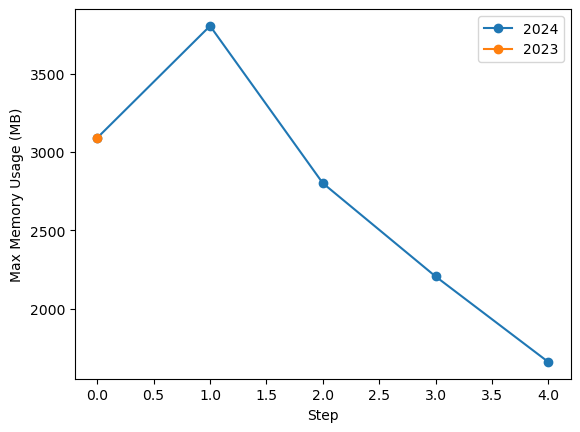

In [34]:
plt.plot(np.arange(len(gen_2024)), gen_2024, marker='o', label='2024')
plt.plot(np.arange(len(gen_2023)), gen_2023, marker='o', label='2023')
plt.xlabel('Step')
plt.ylabel('Max Memory Usage (MB)')
plt.legend()